<a href="https://colab.research.google.com/github/anumolmanoj270-spec/rainfall-analysis-project/blob/main/rainfall%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("weather_rainfall_366x12_68yes_32no.csv")
df.head()

,Temperature,Humidity,WindSpeed,Pressure,CloudCover,Visibility,DewPoint,UVIndex,WindDirection,Precipitation,FeelsLike,Rainfall
0,36,60,14,1003,99,9,17,3,184,0.55,39,Yes
1,23,94,29,1029,16,4,24,1,19,0.11,34,Yes
2,35,83,19,1017,49,2,10,9,95,0.97,36,Yes
3,37,48,2,1027,16,1,17,3,16,0.88,33,Yes
4,25,64,23,998,53,5,19,0,14,0.94,31,Yes


In [ ]:
df.shape

(366, 12)

In [ ]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
WindSpeed,0
Pressure,0
CloudCover,0
Visibility,0
DewPoint,0
UVIndex,0
WindDirection,0
Precipitation,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    366 non-null    int64  
 1   Humidity       366 non-null    int64  
 2   WindSpeed      366 non-null    int64  
 3   Pressure       366 non-null    int64  
 4   CloudCover     366 non-null    int64  
 5   Visibility     366 non-null    int64  
 6   DewPoint       366 non-null    int64  
 7   UVIndex        366 non-null    int64  
 8   WindDirection  366 non-null    int64  
 9   Precipitation  366 non-null    float64
 10  FeelsLike      366 non-null    int64  
 11  Rainfall       366 non-null    object 
dtypes: float64(1), int64(10), object(1)
memory usage: 34.4+ KB


In [ ]:
df.describe()

,Temperature,Humidity,WindSpeed,Pressure,CloudCover,Visibility,DewPoint,UVIndex,WindDirection,Precipitation,FeelsLike
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,29.084699,70.314208,14.939891,1010.213115,50.117486,5.051913,16.948087,4.390710,163.926230,0.466940,29.319672
std,5.799474,17.139785,8.643420,11.852678,28.433337,2.620265,4.396765,2.875084,105.040958,0.288279,5.340873
min,20.000000,40.000000,0.000000,990.000000,0.000000,1.000000,10.000000,0.000000,0.000000,0.000000,20.000000
25%,24.000000,56.000000,7.250000,1000.250000,25.250000,3.000000,13.000000,2.000000,69.000000,0.220000,25.000000
50%,29.000000,70.000000,15.500000,1011.000000,49.000000,5.000000,17.000000,4.000000,163.000000,0.440000,30.000000
75%,34.000000,85.000000,22.000000,1021.000000,74.000000,7.000000,21.000000,7.000000,246.750000,0.680000,33.000000
max,39.000000,99.000000,29.000000,1029.000000,99.000000,9.000000,24.000000,9.000000,359.000000,0.990000,39.000000


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.head()

,Temperature,Humidity,WindSpeed,Pressure,CloudCover,Visibility,DewPoint,UVIndex,WindDirection,Precipitation,FeelsLike,Rainfall
0,36,60,14,1003,99,9,17,3,184,0.55,39,Yes
1,23,94,29,1029,16,4,24,1,19,0.11,34,Yes
2,35,83,19,1017,49,2,10,9,95,0.97,36,Yes
3,37,48,2,1027,16,1,17,3,16,0.88,33,Yes
4,25,64,23,998,53,5,19,0,14,0.94,31,Yes


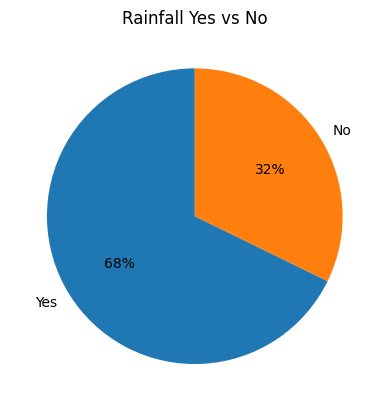

In [ ]:
df.Rainfall.value_counts()
df.Rainfall.value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    startangle=90
)

plt.title("Rainfall Yes vs No")
plt.ylabel("")
plt.show()

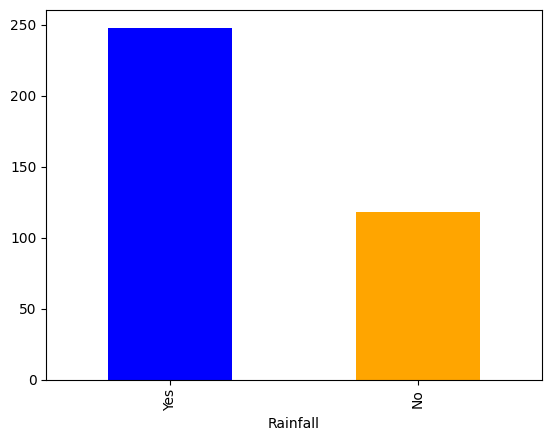

In [ ]:
df.Rainfall.value_counts().plot(kind="bar", color=["blue","orange"])
plt.show()

/tmp/ipykernel_702/4017267088.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Humidity'])


<Axes: xlabel='Humidity', ylabel='Density'>

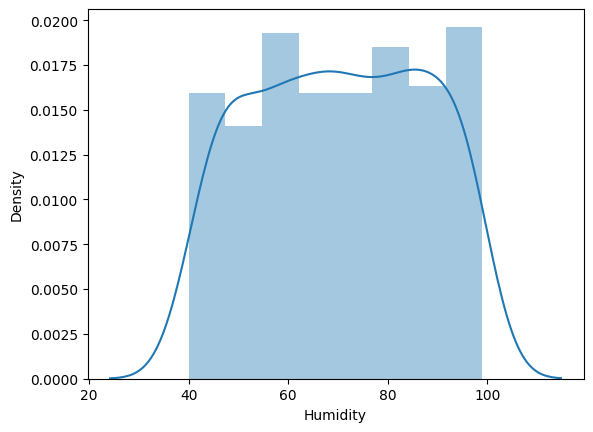

In [ ]:
sns.distplot(df['Humidity'])

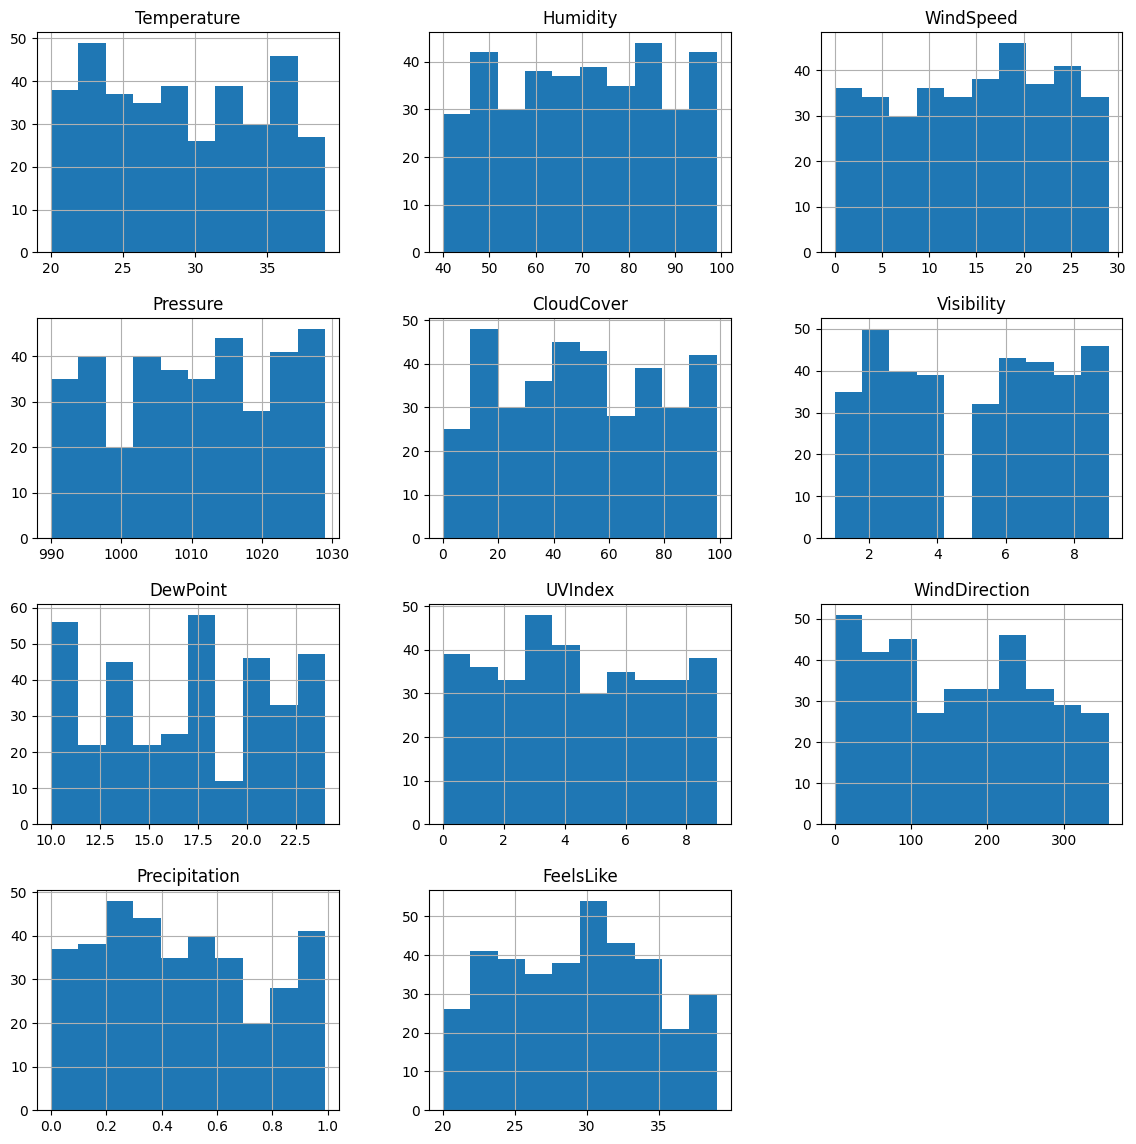

In [ ]:
df.hist(figsize=(14,14))
plt.show()

In [ ]:
sns.pairplot(df,hue='Rainfall')

In [ ]:
sns.scatterplot(x=df['Humidity'], y=df['Rainfall'])
plt.title("Humidity vs Rainfall")
plt.show()

In [ ]:
df.boxplot(figsize=(14,7))

In [ ]:
X = df.drop('Rainfall',axis=1)
Y = df['Rainfall']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=101,shuffle=True)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

dt = DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=10,
    splitter='best'
)

dt.fit(X_train,Y_train)

prediction = dt.predict(X_test)

accuracy_dt = accuracy_score(Y_test,prediction)*100
accuracy_dt

In [ ]:
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, Y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, Y_test)))

In [ ]:
print("Feature importances:\n{}".format(dt.feature_importances_))

In [ ]:
confusion_matrix(Y_test,prediction)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=22)

knn.fit(X_train,Y_train)

prediction_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(Y_test,prediction_knn)*100

print("Accuracy:",accuracy_knn)

In [ ]:
confusion_matrix(Y_test,prediction_knn)